In [4]:
# Modify check_degradation.py with the new v4 stages
import os
import uproot

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

stages = ["fresh", "light", "moderate", "heavy", "severe", "extreme"]
trapping_times = [10000, 10, 5, 2, 1, 0.5]

print(f"\n{'Stage':<12} {'Trap (ns)':<12} {'Pixel Hits':<12} {'% of Fresh':<12}")
print("─" * 50)

fresh_hits = None
for stage, trap in zip(stages, trapping_times):
    path = os.path.join(BASE, f"s2_v4_{stage}.root")
    if not os.path.exists(path):
        print(f"{stage:<12} {trap:<12} MISSING")
        continue
    try:
        f = uproot.open(path)
        hits = int(f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()[0].sum())
        if stage == "fresh":
            fresh_hits = hits
        pct = (hits / fresh_hits * 100) if fresh_hits else 0
        print(f"{stage:<12} {trap:<12} {hits:<12,} {pct:.1f}%")
    except Exception as e:
        print(f"{stage:<12} {trap:<12} ERROR: {e}")
print()


Stage        Trap (ns)    Pixel Hits   % of Fresh  
──────────────────────────────────────────────────
fresh        10000        12,548       100.0%
light        10           12,241       97.6%
moderate     5            11,883       94.7%
heavy        2            10,870       86.6%
severe       1            6,604        52.6%
extreme      0.5          3,008        24.0%



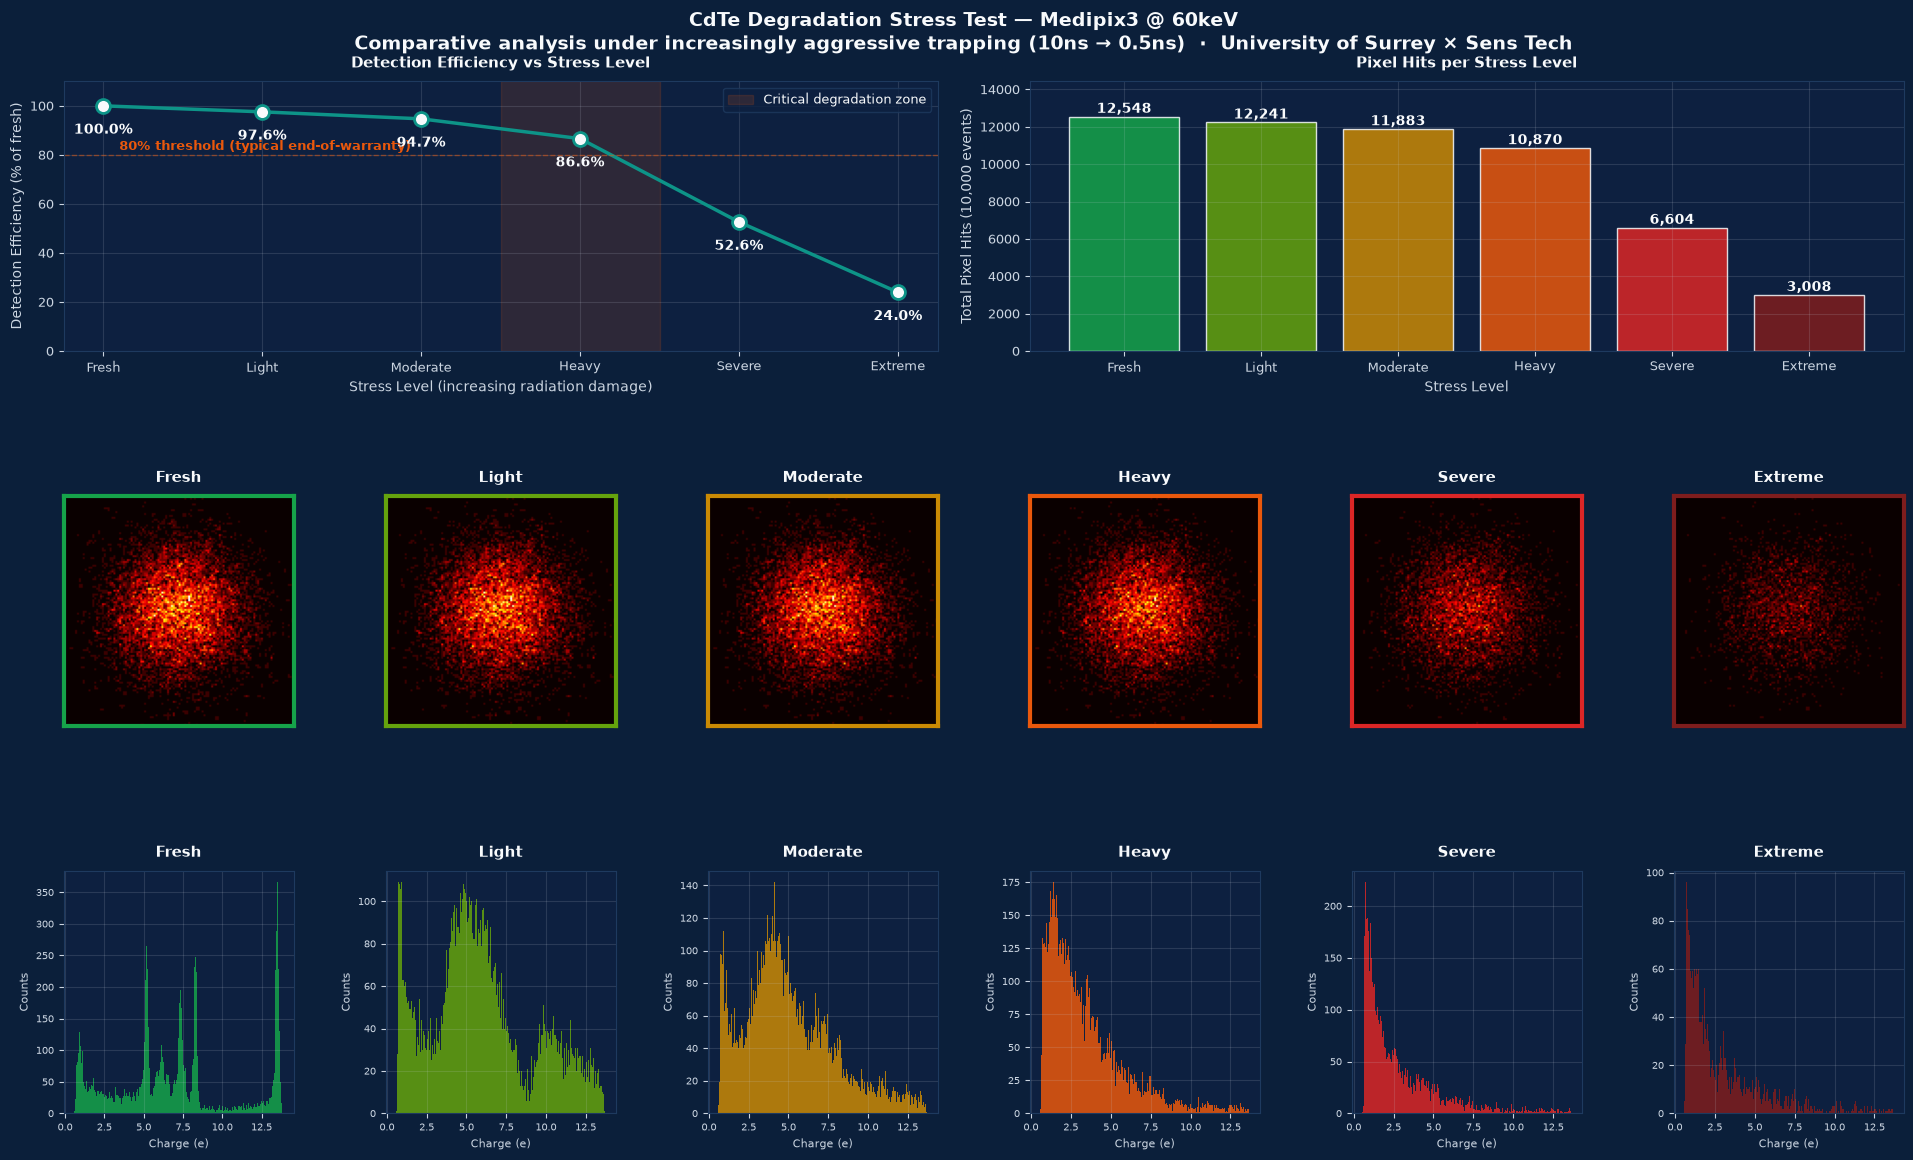


Dashboard saved to: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/degradation_stress_test.png

Stage      Trap (ns)    Hits       % Fresh    Mean Cluster
────────────────────────────────────────────────────────────
fresh      10000        12,548     100.0      1.01        
light      10           12,241     97.6       0.97        
moderate   5            11,883     94.7       0.93        
heavy      2            10,870     86.6       0.82        
severe     1            6,604      52.6       0.71        
extreme    0.5          3,008      24.0       0.66        


In [5]:
"""
Degradation Stress Test — CdTe on Medipix3
Comparative stress testing under increasingly aggressive trapping conditions.
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────
BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

stages   = ["fresh", "light", "moderate", "heavy", "severe", "extreme"]
trapping = [10000, 10, 5, 2, 1, 0.5]
labels   = ["Fresh", "Light", "Moderate", "Heavy", "Severe", "Extreme"]

# ── Extract data ──────────────────────────────────────────────────────────
results = []
hit_maps = []
charge_specs = []

for stage in stages:
    path = os.path.join(BASE, f"s2_v4_{stage}.root")
    f = uproot.open(path)
    pixel_charge = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    cluster_charge = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()
    hit_map = f[f"DetectorHistogrammer/{DET}/hit_map;1"].to_numpy()
    cluster_size = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()

    hits = int(pixel_charge[0].sum())
    mean_charge = np.average(pixel_charge[1][:-1], weights=pixel_charge[0] + 1e-9)
    mean_cluster = np.average(cluster_size[1][:-1], weights=cluster_size[0] + 1e-9)

    results.append({
        "stage": stage,
        "hits": hits,
        "mean_charge": mean_charge,
        "mean_cluster": mean_cluster,
    })
    hit_maps.append(hit_map[0])
    charge_specs.append(pixel_charge)

fresh_hits = results[0]["hits"]
for r in results:
    r["pct"] = (r["hits"] / fresh_hits) * 100

# ── Style ─────────────────────────────────────────────────────────────────
NAVY  = "#0B1F3A"
WHITE = "#F8FAFC"
LGRAY = "#CBD5E1"
GRAY  = "#64748B"
DARK  = "#1E293B"

# Colour gradient — green (healthy) to red (failing)
COLORS = ["#16A34A", "#65A30D", "#CA8A04", "#EA580C", "#DC2626", "#7F1D1D"]

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY)
    ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

# ── Build figure ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(NAVY)

gs = gridspec.GridSpec(3, 6, figure=fig,
                       hspace=0.55, wspace=0.4,
                       left=0.05, right=0.97, top=0.92, bottom=0.06,
                       height_ratios=[1, 0.9, 0.9])

# ── PANEL 1: The degradation curve (large) ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :3])
style_ax(ax1, "Detection Efficiency vs Stress Level")
pcts = [r["pct"] for r in results]

ax1.plot(range(len(labels)), pcts,
         color="#0D9488", linewidth=2.5, marker="o", markersize=10,
         markerfacecolor=WHITE, markeredgewidth=2)

# Highlight the "knee" between heavy and severe
ax1.axvspan(2.5, 3.5, alpha=0.15, color="#EA580C", label="Critical degradation zone")
ax1.axhline(y=80, color="#EA580C", linestyle="--", alpha=0.5, linewidth=1)
ax1.text(0.1, 82, "80% threshold (typical end-of-warranty)",
         color="#EA580C", fontsize=9, fontweight="bold")

# Annotate each point
for i, (l, p) in enumerate(zip(labels, pcts)):
    ax1.annotate(f"{p:.1f}%",
                 xy=(i, p), xytext=(0, -20), textcoords="offset points",
                 ha="center", color=WHITE, fontsize=10, fontweight="bold")

ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_xlabel("Stress Level (increasing radiation damage)")
ax1.set_ylabel("Detection Efficiency (% of fresh)")
ax1.set_ylim(0, 110)
ax1.legend(loc="upper right", fontsize=9, labelcolor=WHITE,
           facecolor="#0D2040", edgecolor="#1E3A5F")

# ── PANEL 2: Stress level breakdown bars ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 3:])
style_ax(ax2, "Pixel Hits per Stress Level")

bars = ax2.bar(labels, [r["hits"] for r in results], color=COLORS,
               alpha=0.85, edgecolor=WHITE, linewidth=1)
for bar, r in zip(bars, results):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{r['hits']:,}",
             ha="center", color=WHITE, fontsize=10, fontweight="bold")

ax2.set_xlabel("Stress Level")
ax2.set_ylabel("Total Pixel Hits (10,000 events)")
ax2.set_ylim(0, max(r["hits"] for r in results) * 1.15)

# ── PANEL 3-8: Hit maps for each stage ────────────────────────────────────
for i, (label, color) in enumerate(zip(labels, COLORS)):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"{label}")

    # Crop hit map to central region for clarity
    hm = hit_maps[i]
    center = hm.shape[0] // 2
    crop = 60
    hm_crop = hm[center-crop:center+crop, center-crop:center+crop]

    im = ax.imshow(hm_crop, cmap="hot", origin="lower", aspect="equal",
                   vmax=hit_maps[0].max())  # use same scale as fresh
    ax.set_xticks([])
    ax.set_yticks([])

    # Border colour by stress
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

# ── PANEL 9-14: Charge spectra ────────────────────────────────────────────
for i, (label, color) in enumerate(zip(labels, COLORS)):
    ax = fig.add_subplot(gs[2, i])
    style_ax(ax, f"{label}")

    vals = charge_specs[i]
    m = vals[0] > 0
    ax.bar(vals[1][:-1][m], vals[0][m], width=np.diff(vals[1])[m],
           color=color, alpha=0.85)
    ax.set_xlabel("Charge (e)", fontsize=8)
    ax.set_ylabel("Counts", fontsize=8)
    ax.tick_params(labelsize=7)

# Main title
fig.suptitle(
    "CdTe Degradation Stress Test — Medipix3 @ 60keV\n"
    "Comparative analysis under increasingly aggressive trapping (10ns → 0.5ns)  ·  University of Surrey × Sens Tech",
    fontsize=14, fontweight="bold", color=WHITE, y=0.98
)

# ── Save ──────────────────────────────────────────────────────────────────
out_dir = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks")
os.makedirs(out_dir, exist_ok=True)
out = os.path.join(out_dir, "degradation_stress_test.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\nDashboard saved to: {out}")

# ── Print summary ─────────────────────────────────────────────────────────
print(f"\n{'Stage':<10} {'Trap (ns)':<12} {'Hits':<10} {'% Fresh':<10} {'Mean Cluster':<12}")
print("─" * 60)
for r, trap in zip(results, trapping):
    print(f"{r['stage']:<10} {trap:<12} {r['hits']:<10,} {r['pct']:<10.1f} {r['mean_cluster']:<12.2f}")